# **EDA of Lung-PET-CT-Dx | Clinical and Demographic Data**

Exploratory Data Analysis of Clinical and Demographic Data

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from scipy import stats
from src.features.statistical_analysis import mixed_correlation_matrix, shapiro_wilk_test, dagostino_test, univariate_analysis
from src.features.dimensionality_reduction import (
    preprocess_for_reduction, apply_pca, apply_famd, gower_distance, apply_umap,
)
from src.utils.visualize import plot_correlation_matrix, plot_pca, plot_famd, plot_umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
COLORS = sns.color_palette("Set2", 3)
C1, C2, C3 = COLORS

In [2]:
df = pd.read_excel('../../data/raw/lung-pet-ct/clinical_data.xlsx')
df = df.rename(columns={"Histopathological grading": "His Grading", "weight (kg)": "Weight"})

## **Distribution analysis**

In [3]:
df

,No.,NewPatientID,Sex,Age,Weight,T-Stage,N-Stage,M-Stage,His Grading,Smoking History
0,1,A0001,M,58.0,65.0,2b,3,1b,G3,1
1,2,A0002,F,53.0,55.0,2b,1,0,NaN,0
2,3,A0003,M,60.0,62.0,1c,1,0,G3,0
3,4,A0004,F,48.0,56.0,1c,3,0,NaN,0
4,5,A0005,M,70.0,75.0,1b,0,0,G2,1
...,...,...,...,...,...,...,...,...,...,...
350,351,G0057,M,72.0,67.5,1c,0,0,G2,1
351,352,G0058,M,57.0,55.0,4,0,0,NaN,1
352,353,G0059,M,53.0,62.0,1b,0,0,NaN,1
353,354,G0060,M,57.0,74.0,2a,1,0,NaN,0


In [4]:
df.columns

Index(['No.', 'NewPatientID', 'Sex', 'Age', 'Weight', 'T-Stage', 'N-Stage',
       'M-Stage', 'His Grading', 'Smoking History'],
      dtype='object')

His Grading column has dirty values, where ' G1' value means the same than 'G1' value. It is done a preprocess to unicate this unconsistent values:

In [5]:
# ' G1'/'G1' differ only by a leading space, and 'G1-2'/'G1-G2' (resp.
# 'G2-3'/'G2-G3') are two spellings of the same grade. Normalise them so
# each histological grade maps to a single, consistent category.
grade_map = {"G1-2": "G1-G2", "G2-3": "G2-G3"}
df["His Grading"] = df["His Grading"].str.strip().replace(grade_map)
df["His Grading"].value_counts(dropna=False)

His Grading
NaN      210
G3        62
G2-G3     35
G2        27
G1        12
G1-G2      9
Name: count, dtype: int64

## Missing values

In [6]:
df_NA = df.isna().sum()
df_NA=df_NA.sort_values(ascending=False)
df_NA.head(len(df.columns))

His Grading        210
Weight               4
Age                  1
No.                  0
NewPatientID         0
Sex                  0
T-Stage              0
N-Stage              0
M-Stage              0
Smoking History      0
dtype: int64

His Grading has lots of NA values. Beside that. Weight and age have low NaN data that can be imputed per the median value from each column. For the next experiments.

In [7]:
# Weight (4) and Age (1) have only a handful of missing values, so we impute
# them with the column median to keep those patients in later experiments.
# 'His Grading' (~59% missing, not at random) is intentionally left as NaN here.
for col in ["Weight", "Age"]:
    df[col] = df[col].fillna(df[col].median())

df.isna().sum().sort_values(ascending=False)

His Grading        210
No.                  0
NewPatientID         0
Sex                  0
Age                  0
Weight               0
T-Stage              0
N-Stage              0
M-Stage              0
Smoking History      0
dtype: int64

## Distribution of variables

### Categorical

In [8]:
categorical_variables = ["His Grading", "T-Stage", "N-Stage", "M-Stage", "Sex", "Smoking History"]
numerical_variables = ["Weight", "Age"]

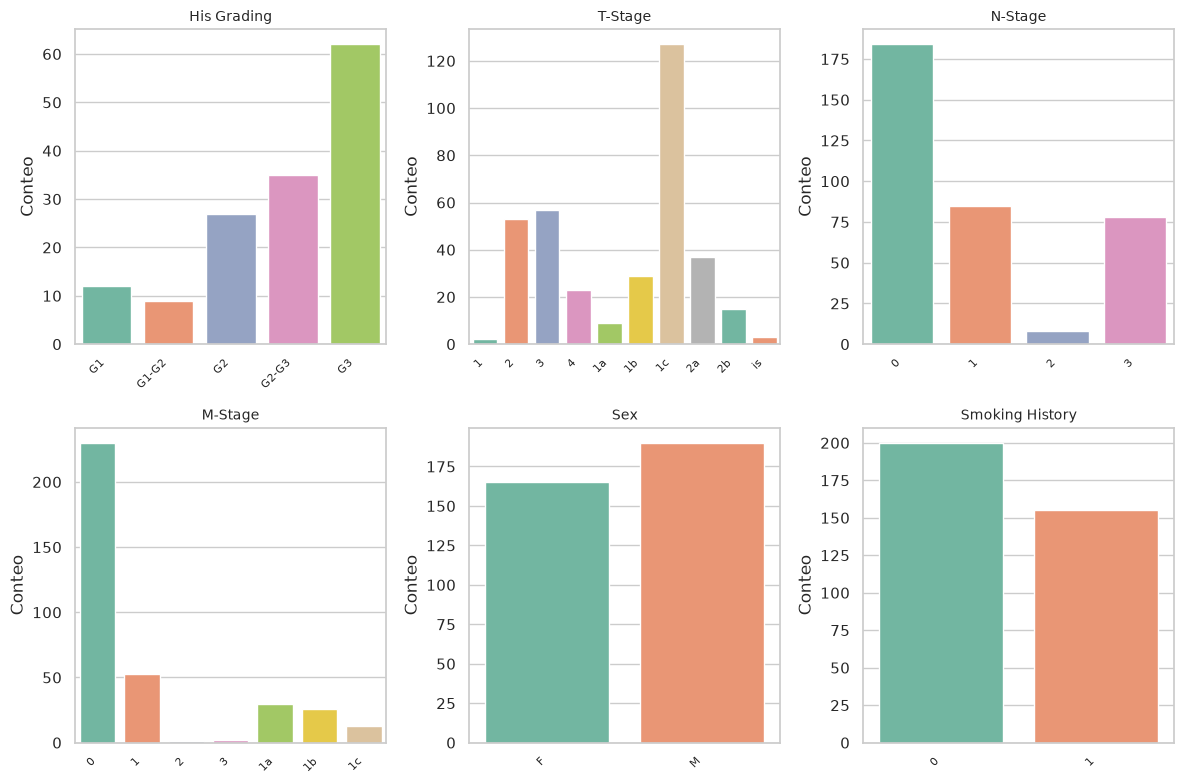

In [9]:
categorical_plot_df = df[categorical_variables]
n_cols = 3
n_plots = len(categorical_variables)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, column in enumerate(categorical_variables):
    ax = axes[i]
    values = categorical_plot_df[column].dropna()
    if values.empty:
        ax.set_visible(False)
        continue
    plot_df = pd.DataFrame({column: values})
    plot_df[column] = plot_df[column].apply(
        lambda x: str(int(x)) if isinstance(x, (int, float, np.integer, np.floating)) and float(x).is_integer() else str(x)
    )

    def sort_key(x):
        try:
            return (0, float(x))
        except ValueError:
            return (1, str(x).lower())

    order = sorted(plot_df[column].unique(), key=sort_key)

    palette = sns.color_palette("Set2", len(order))

    sns.countplot(
        data=plot_df,
        x=column,
        hue=column,
        order=order,
        hue_order=order,
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(column, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Conteo")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_ha('right')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../../results/reports/EDA/clinical_data/distributions/categorical.png', dpi=300, bbox_inches='tight')
plt.show()

### Numerical

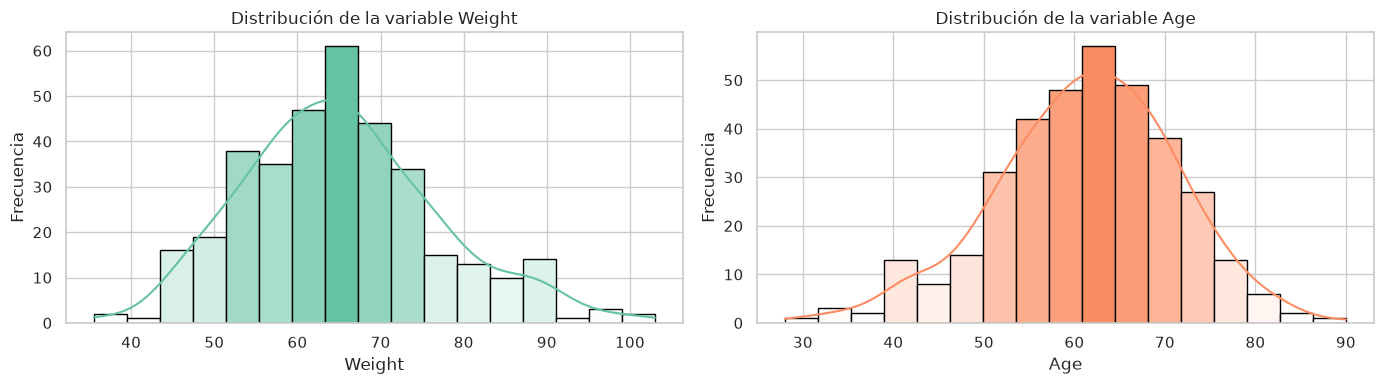

In [10]:
numerical_plot_df = df[numerical_variables]

n_cols = 2
n_vars = len(numerical_plot_df.columns)
n_rows = int(np.ceil(n_vars / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)
base_colors = sns.color_palette("Set2", n_vars)
for i, (ax, column) in enumerate(zip(axes, numerical_plot_df.columns)):
    values = pd.to_numeric(numerical_plot_df[column], errors="coerce").dropna()
    sns.histplot(values, kde=True, ax=ax, color=base_colors[i], edgecolor="black")
    patches = ax.patches
    heights = [p.get_height() for p in patches]
    if len(heights) > 0 and max(heights) > min(heights):
        norm = mcolors.Normalize(vmin=min(heights), vmax=max(heights))
        base_color = mcolors.to_rgb(base_colors[i])
        for p in patches:
            intensity = norm(p.get_height())
            color = (
                1 - intensity + intensity * base_color[0],
                1 - intensity + intensity * base_color[1],
                1 - intensity + intensity * base_color[2],
            )
            p.set_facecolor(color)

    ax.set_title(f"Distribución de la variable {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frecuencia")
for ax in axes[n_vars:]:
    ax.remove()

plt.tight_layout()
plt.savefig('../../results/reports/EDA/clinical_data/distributions/numerical.png', dpi=300, bbox_inches='tight')
plt.show()

### Q-Q plot for numerical variables

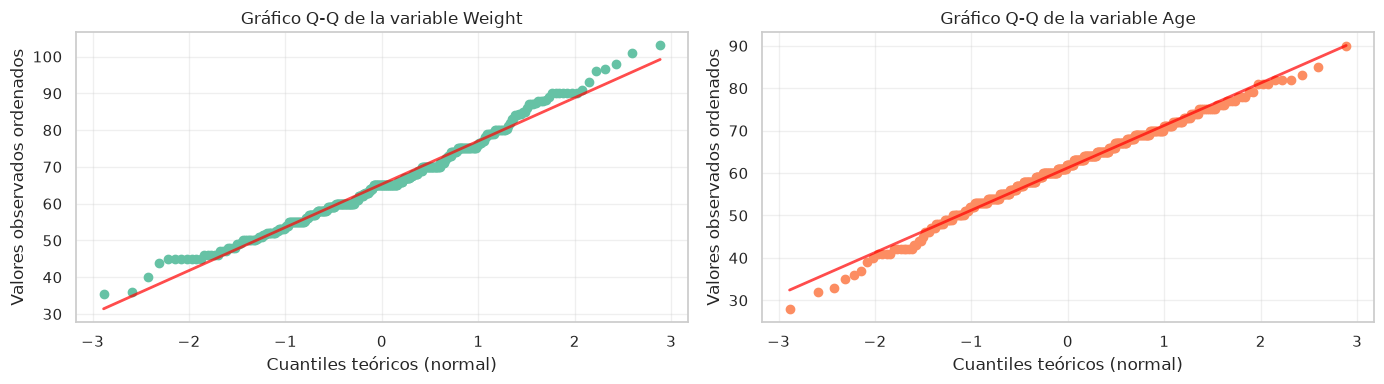

In [11]:
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes2 = np.array(axes2).reshape(-1)

for i, (ax, column) in enumerate(zip(axes2, numerical_plot_df.columns)):
    values = pd.to_numeric(numerical_plot_df[column], errors="coerce").dropna()
    # Q-Q plot
    stats.probplot(values, dist="norm", plot=ax)
    # probplot pone sus propias etiquetas ('Probability Plot',
    # 'Theoretical quantiles', 'Ordered Values'); se sobrescriben después.
    ax.set_title(f"Gráfico Q-Q de la variable {column}")
    ax.set_xlabel("Cuantiles teóricos (normal)")
    ax.set_ylabel("Valores observados ordenados")
    ax.grid(True, alpha=0.3)
    # Añadir línea de referencia y mejorar colores
    ax.get_lines()[0].set_color(base_colors[i])
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linewidth(2)
    ax.get_lines()[1].set_alpha(0.7)

for ax in axes2[n_vars:]:
    ax.remove()

plt.tight_layout()
plt.savefig('../../results/reports/EDA/clinical_data/qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Gaussian analysis for numerical variables

In [12]:
numerical_df = df[numerical_variables]

shapiro_results = shapiro_wilk_test(numerical_df)
dagostino_results = dagostino_test(numerical_df)

results_df = pd.DataFrame([
    {
        'variable': var,
        'n': numerical_df[var].dropna().shape[0],
        'shapiro_Wilk_p_value': shapiro_results[var]['p_value'],
        'dagostino_pearson_p_value': dagostino_results[var]['p_value'],
        'is_normal': shapiro_results[var]['is_normal'],
    }
    for var in numerical_df.columns
])

In [13]:
results_df

,variable,n,shapiro_Wilk_p_value,dagostino_pearson_p_value,is_normal
0,Weight,355,0.000642,0.003699,False
1,Age,355,0.057042,0.034433,True


## **Correlation analysis**

In [14]:
# Variables to include in the mixed correlation matrix.
correlation_variables = categorical_variables + numerical_variables

# Use the normality results to choose Pearson vs Spearman for numeric-numeric pairs.
normality_variables = shapiro_wilk_test(df[numerical_variables])

corr_matrix, method_matrix, variable_types = mixed_correlation_matrix(
    df,
    columns=correlation_variables,
    categorical_columns=categorical_variables,
    numerical_columns=numerical_variables,
    normality_variables=normality_variables,
)
corr_matrix

,His Grading,T-Stage,N-Stage,M-Stage,Sex,Smoking History,Weight,Age
His Grading,1.000000,0.302146,0.378706,0.239081,0.339526,0.205854,0.175931,0.130265
T-Stage,0.302146,1.000000,0.242062,0.180362,0.196950,0.256692,0.139894,0.152423
N-Stage,0.378706,0.242062,1.000000,0.221860,0.113455,0.129284,0.070453,0.051465
M-Stage,0.239081,0.180362,0.221860,1.000000,0.084339,0.159545,0.130627,0.213798
Sex,0.339526,0.196950,0.113455,0.084339,1.000000,0.347800,0.456421,0.003650
Smoking History,0.205854,0.256692,0.129284,0.159545,0.347800,1.000000,0.072090,0.172224
Weight,0.175931,0.139894,0.070453,0.130627,0.456421,0.072090,1.000000,-0.050820
Age,0.130265,0.152423,0.051465,0.213798,0.003650,0.172224,-0.050820,1.000000


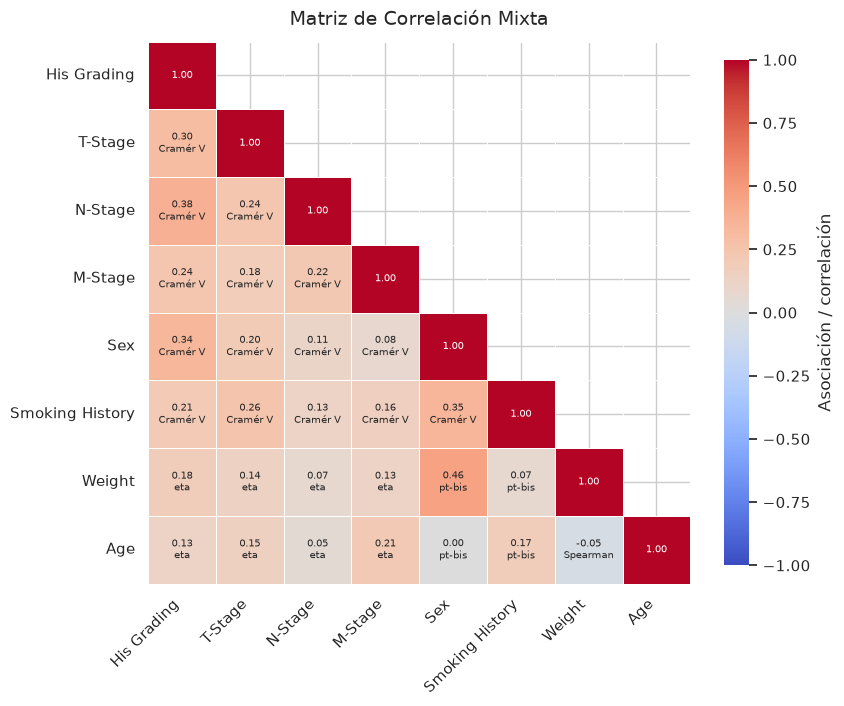

(<Figure size 860x760 with 2 Axes>,
 <Axes: title={'center': 'Matriz de Correlación Mixta'}>)

In [15]:
plot_correlation_matrix(
    corr_matrix,
    title="Matriz de Correlación Mixta",
    method_matrix=method_matrix,
    filename='../../results/reports/EDA/clinical_data/correlation/mixed_correlation_matrix.png',
    languaje="es"
)

## Unsupervised Analysis

### PCA

In [16]:
CAT = ["His Grading", "T-Stage", "N-Stage", "M-Stage", "Sex", "Smoking History"]
NUM = ["Weight", "Age"]

def matriz_cruda(df):
    """El escalado actual: numéricas estandarizadas, dummies tal cual."""
    partes = [pd.DataFrame(StandardScaler().fit_transform(df[NUM]), columns=NUM, index=df.index)]
    partes += [pd.get_dummies(df[c].astype(str), prefix=c).astype(float) for c in CAT]
    return pd.concat(partes, axis=1)


def matriz_equilibrada(df):
    """Cada variable aporta varianza total 1, sea numérica o categórica."""
    partes = [pd.DataFrame(StandardScaler().fit_transform(df[NUM]), columns=NUM, index=df.index)]
    for c in CAT:
        d = pd.get_dummies(df[c].astype(str), prefix=c).astype(float)
        partes.append(d / np.sqrt(d.var(ddof=0).sum()))
    return pd.concat(partes, axis=1)


def peso_por_variable(X, n=2):
    """Cuánto de cada componente explica cada variable (suma de cargas al cuadrado)."""
    p = PCA(n_components=3).fit(X)
    L = pd.DataFrame(p.components_[:n].T, index=X.columns,
                     columns=[f"PC{i+1}" for i in range(n)])
    L["var"] = [next((c for c in CAT + NUM if str(i).startswith(c)), i) for i in L.index]
    return 100 * L.groupby("var")[[f"PC{i+1}" for i in range(n)]].apply(lambda g: (g ** 2).sum()), p


peso_crudo, pca_crudo = peso_por_variable(matriz_cruda(df))
peso_eq, pca_eq = peso_por_variable(matriz_equilibrada(df))
X_eq = PCA(n_components=3).fit_transform(matriz_equilibrada(df))

comparacion = pd.concat(
    {"escalado actual": peso_crudo, "escalado equilibrado": peso_eq}, axis=1).round(1)
print(f"varianza en PC1+PC2 — actual: {100*pca_crudo.explained_variance_ratio_[:2].sum():.1f}%"
      f" | equilibrado: {100*pca_eq.explained_variance_ratio_[:2].sum():.1f}%")
comparacion.sort_values(("escalado equilibrado", "PC1"), ascending=False)

varianza en PC1+PC2 — actual: 40.3% | equilibrado: 35.2%


escalado actual       escalado equilibrado      
                            PC1   PC2                  PC1   PC2
var                                                             
Sex                        18.7   3.3                 45.6   0.9
Weight                     72.5   1.6                 29.0  16.6
Smoking History             1.7   8.5                 22.5  23.9
T-Stage                     0.4   0.8                  0.9   0.8
N-Stage                     0.4   0.1                  0.7   1.2
His Grading                 0.4   0.1                  0.6   0.3
Age                         5.9  85.3                  0.5  55.0
M-Stage                     0.0   0.4                  0.1   1.3

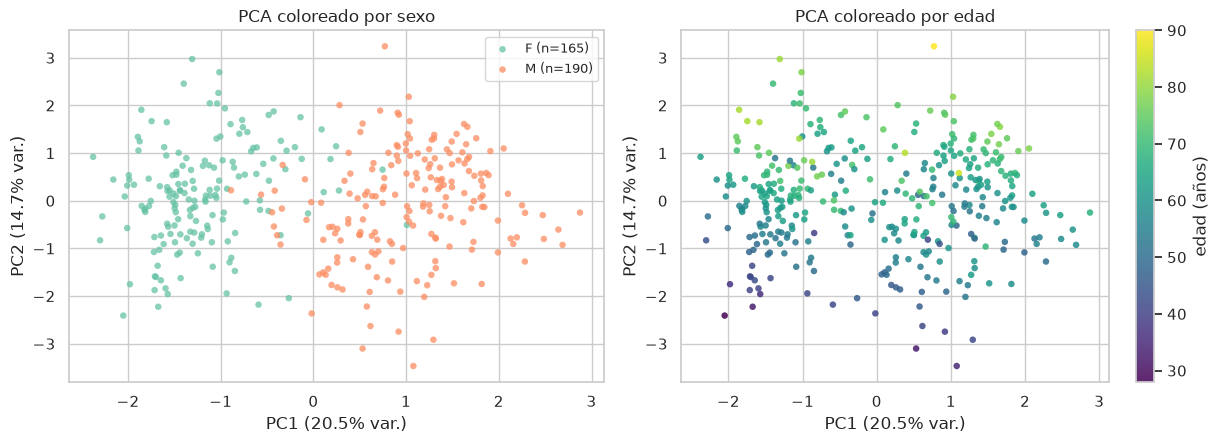

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) coloreado por sexo: la variable que domina PC1 tras equilibrar.
for sexo, color in [("F", C1), ("M", C2)]:
    m = (df["Sex"] == sexo).to_numpy()
    axes[0].scatter(X_eq[m, 0], X_eq[m, 1], s=22, alpha=0.75, color=color,
                    label=f"{sexo} (n={m.sum()})", zorder=3, edgecolors="none")
axes[0].set_title("PCA coloreado por sexo")
axes[0].legend(loc="upper right", fontsize=9)

# (b) coloreado por edad: continuo, sin grupos.
s = axes[1].scatter(X_eq[:, 0], X_eq[:, 1], c=df["Age"], s=22, cmap="viridis",
                    alpha=0.85, zorder=3, edgecolors="none")
plt.colorbar(s, ax=axes[1], label="edad (años)")
axes[1].set_title("PCA coloreado por edad")

for ax in axes:
    ax.set_xlabel(f"PC1 ({100*pca_eq.explained_variance_ratio_[0]:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({100*pca_eq.explained_variance_ratio_[1]:.1f}% var.)")
plt.tight_layout()
plt.savefig('../../results/reports/EDA/clinical_data/pca_colored.png', dpi=300, bbox_inches='tight')
plt.show()

### UMAP

In [19]:
def embedding_umap(datos, cats, nums, seed=42):
    D = gower_distance(datos, categorical_columns=cats, numerical_columns=nums)
    return apply_umap(D, n_components=2, metric="precomputed")


E_umap = embedding_umap(df, CAT, NUM)
siluetas = {v: silhouette_score(E_umap, df[v].astype(str)) for v in CAT}

# Test de exclusión: reconstruir el embedding SIN la variable y volver a medir.
exclusion = {}
for v in ["Sex", "Smoking History"]:
    cats = [c for c in CAT if c != v]
    E = embedding_umap(df, cats, NUM)
    exclusion[v] = silhouette_score(E, df[v].astype(str))


tabla = pd.DataFrame({
    "silueta (variable dentro)": pd.Series(siluetas),
    "silueta (variable excluida)": pd.Series(exclusion),
}).sort_values("silueta (variable dentro)", ascending=False)
tabla["se mantiene"] = np.where(tabla["silueta (variable excluida)"].isna(), "-",
                                np.where(tabla["silueta (variable excluida)"] > 0.25, "sí", "no"))
tabla.round(3)

,silueta (variable dentro),silueta (variable excluida),se mantiene
Sex,0.533,0.087,no
Smoking History,0.267,0.107,no
N-Stage,-0.018,NaN,-
His Grading,-0.176,NaN,-
M-Stage,-0.206,NaN,-
T-Stage,-0.228,NaN,-
